## Load checkpoints


In [1]:
checkpoint_dir = "./checkpoints/cifar10"

In [2]:
from pathlib import Path

checkpoint_dir = Path(checkpoint_dir)
checkpoint_paths = {}
for p in checkpoint_dir.glob("*.pt"):
    epoch_num = int(p.stem.split("_")[2])
    checkpoint_paths[epoch_num] = p

In [3]:
import yaml

with open(checkpoint_dir / "hparams.yaml") as f:
    hparams = yaml.safe_load(f)

In [4]:
print("Keys for hparams")
for key in hparams:
    print(f"- {key}")
    for subkey in hparams[key]:
        print(f"  - {subkey}")

Keys for hparams
- ddpm
  - betas
  - num_steps
- noise_prediction_model
  - bridge_dim
  - input_dim
  - layer_dims
  - output_dim
  - time_embedding_dim
- training
  - num_epochs


In [5]:
device = "mps"

In [6]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid


def plot(tensor, title, nrow=8):
    grid = make_grid(tensor, nrow=nrow, normalize=True, scale_each=True)

    plt.figure(figsize=(6, 6))
    # permute to HWC for matplotlib
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis("off")
    plt.title(title)
    plt.show()

In [7]:
import torch

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

## Check forward process

When an original image is given, the forward process should gradually convert the image
into a pure Gaussian noise.


In [2]:
dataset_root = "../../datasets"

In [18]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)
dataset = datasets.CIFAR10(
    root=dataset_root, transform=transform, train=False, download=True
)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=2)
x_0, _ = next(iter(dataloader))

/Users/jihun/Library/CloudStorage/GoogleDrive-login@jihunchoi.com/My Drive/Workspace/jihun-personal-gym/diffusion-models/ddpm/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [28]:
from ddpm.forward import DDPMForwardProcess

forward_process = DDPMForwardProcess(betas=hparams["ddpm"]["betas"])

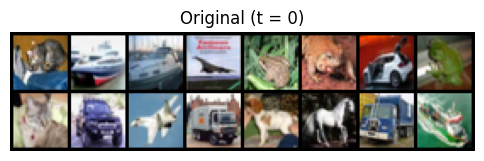

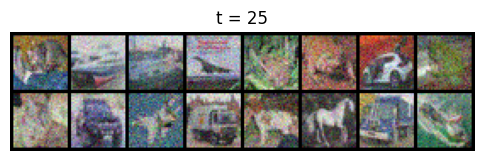

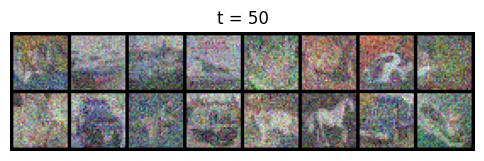

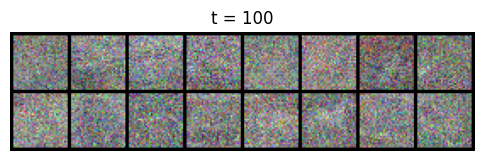

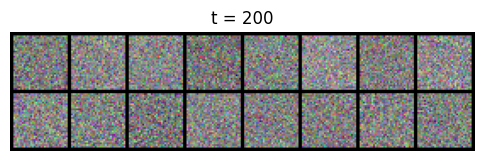

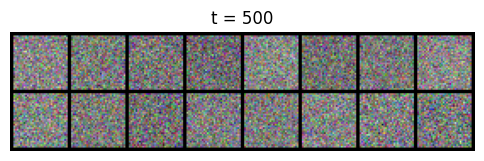

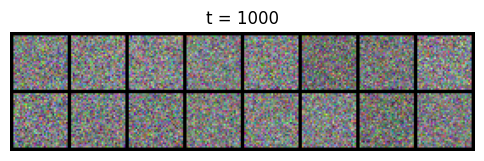

In [ ]:
import torch

plot_schedule = [25, 50, 100, 200, 500, 1000]

plot(x_0, title="Original (t = 0)")

x = x_0
for t in range(len(hparams["ddpm"]["betas"])):
    x = x.to(device)
    t_tensor = torch.tensor([t] * x.size(0), dtype=torch.long).to(device)
    x, _ = forward_process(x, t_tensor)

    if t + 1 in plot_schedule:
        plot(x, title=f"t = {t + 1}")

## Sampling


In [8]:
from diffusion_common import ResUNet

from ddpm.sampling import DDPMSampler

noise_prediction_model = ResUNet(**hparams["noise_prediction_model"])
sampler = DDPMSampler(
    betas=hparams["ddpm"]["betas"], noise_predictor=noise_prediction_model
)

sampler.to(device)
sampler.eval()

DDPMSampler(
  (noise_predictor): ResUNet(
    (time_embedder): SinusoidalEmbedding()
    (time_mlp): Sequential(
      (0): Linear(in_features=128, out_features=512, bias=True)
      (1): ReLU()
      (2): Linear(in_features=512, out_features=128, bias=True)
    )
    (encoders): ModuleList(
      (0): ResUNetEncoderBlock(
        (res_block): ResUNetResidualBlock(
          (conv1): Sequential(
            (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (time_proj): Linear(in_features=128, out_features=64, bias=True)
          (skip_conv): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
          (conv2): Sequential(
            (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (1): ReLU()
            (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
        )
      )
      (1): ResUNetEncoderBlock(
        (res_block): ResUNetResidualBlock(
          (conv1): 

In [12]:
x_t = torch.randn(16, 3, 32, 32, device=device)

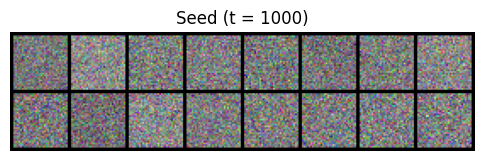

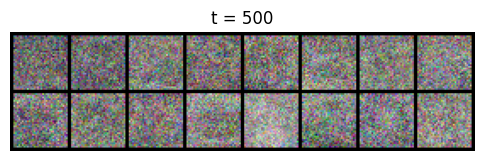

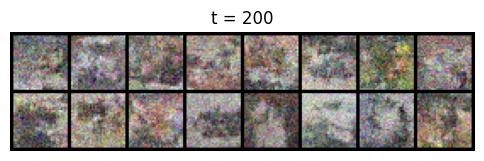

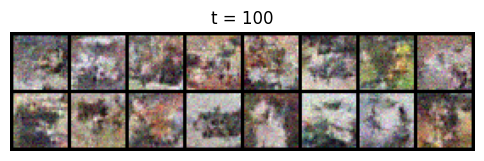

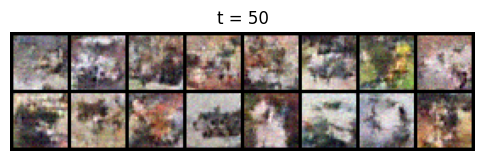

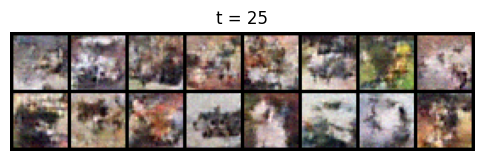

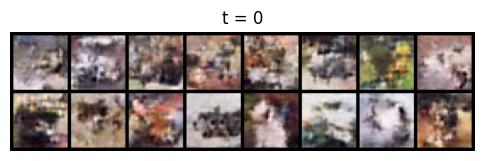

In [13]:
plot(x_t, title=f"Seed (t = {len(hparams['ddpm']['betas'])})")

checkpoint_path = checkpoint_paths[20]
ckpt = torch.load(checkpoint_path, map_location=device)
noise_prediction_model.load_state_dict(ckpt["model_state_dict"])

max_t = len(hparams["ddpm"]["betas"]) - 1
x = x_t
plot_schedule = [0, 25, 50, 100, 200, 500]

for t in range(max_t, -1, -1):
    x = x.to(device)
    t_tensor = torch.tensor([t] * x.size(0), dtype=torch.long).to(device)
    x, _ = sampler(x, t_tensor)

    if t in plot_schedule:
        plot(x, title=f"t = {t}")

## Sample quality per checkpoint


In [15]:
x_t = torch.randn(8, 3, 32, 32, device=device)

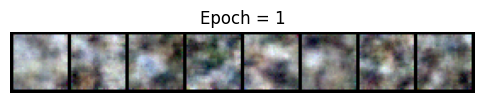

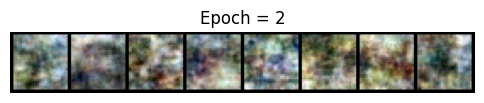

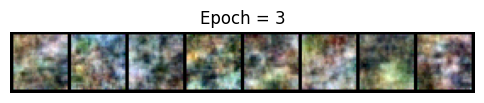

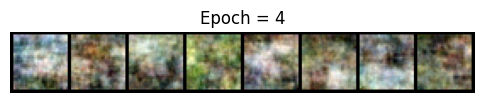

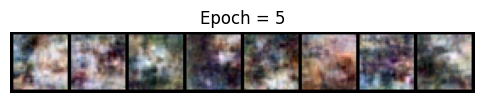

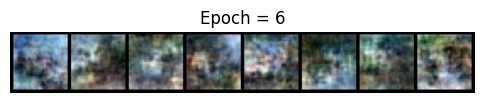

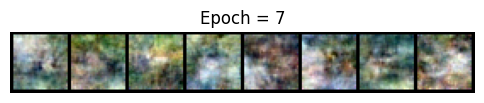

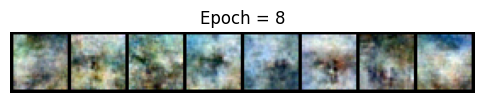

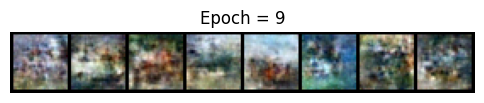

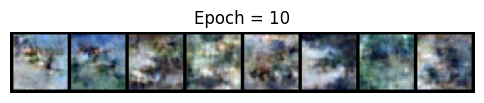

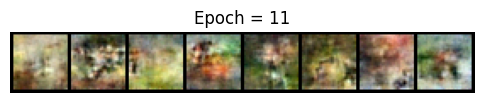

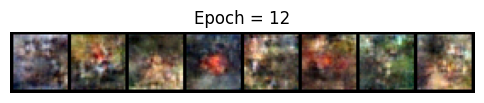

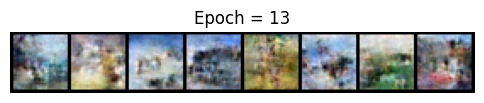

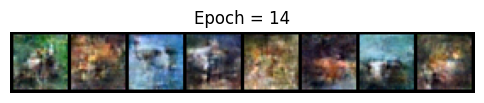

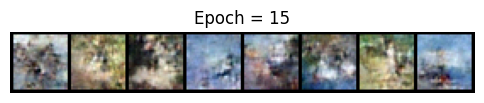

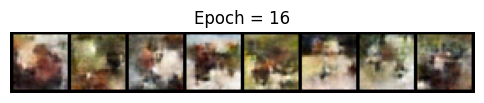

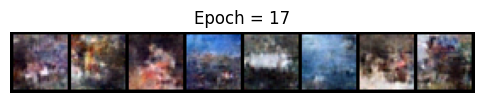

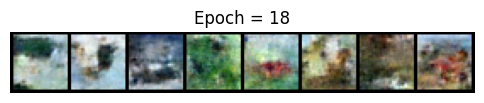

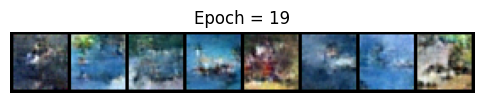

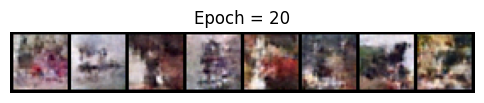

In [16]:
for epoch_num in range(1, 21):
    checkpoint_path = checkpoint_paths[epoch_num]
    ckpt = torch.load(checkpoint_path, map_location=device)
    noise_prediction_model.load_state_dict(ckpt["model_state_dict"])

    max_t = len(hparams["ddpm"]["betas"]) - 1
    x = x_t

    for t in range(max_t, -1, -1):
        x = x.to(device)
        t_tensor = torch.tensor([t] * x.size(0), dtype=torch.long).to(device)
        x, _ = sampler(x, t_tensor)

    plot(x, title=f"Epoch = {epoch_num}")